In [154]:
import pandas as pd
import numpy as np
import seaborn as sns

In [155]:
df = pd.read_csv('bank-full.csv', sep=';')
df.head().T

,0,1,2,3,4
age,58,44,33,47,33
job,management,technician,entrepreneur,blue-collar,unknown
marital,married,single,married,married,single
education,tertiary,secondary,secondary,unknown,unknown
default,no,no,no,no,no
balance,2143,29,2,1506,1
housing,yes,yes,yes,yes,no
loan,no,no,yes,no,no
contact,unknown,unknown,unknown,unknown,unknown
day,5,5,5,5,5


## features

In [156]:
cols = ['age',
'job',
'marital',
'education',
'balance',
'housing',
'contact',
'day',
'month',
'duration',
'campaign',
'pdays',
'previous',
'poutcome',
'y']

## data preparation

In [157]:
df = df[cols]
df.head().T

,0,1,2,3,4
age,58,44,33,47,33
job,management,technician,entrepreneur,blue-collar,unknown
marital,married,single,married,married,single
education,tertiary,secondary,secondary,unknown,unknown
balance,2143,29,2,1506,1
housing,yes,yes,yes,yes,no
contact,unknown,unknown,unknown,unknown,unknown
day,5,5,5,5,5
month,may,may,may,may,may
duration,261,151,76,92,198


In [158]:
df.dtypes

age           int64
job          object
marital      object
education    object
balance       int64
housing      object
contact      object
day           int64
month        object
duration      int64
campaign      int64
pdays         int64
previous      int64
poutcome     object
y            object
dtype: object

In [159]:
df.isnull().sum()

age          0
job          0
marital      0
education    0
balance      0
housing      0
contact      0
day          0
month        0
duration     0
campaign     0
pdays        0
previous     0
poutcome     0
y            0
dtype: int64

## Question 1

In [160]:
df['education'].value_counts(ascending=False)

education
secondary    23202
tertiary     13301
primary       6851
unknown       1857
Name: count, dtype: int64

## Question 2

In [161]:
numerical = list(df.dtypes[df.dtypes == 'int64'].index)
numerical

['age', 'balance', 'day', 'duration', 'campaign', 'pdays', 'previous']

In [162]:
df[numerical].corr()

,age,balance,day,duration,campaign,pdays,previous
age,1.000000,0.097783,-0.009120,-0.004648,0.004760,-0.023758,0.001288
balance,0.097783,1.000000,0.004503,0.021560,-0.014578,0.003435,0.016674
day,-0.009120,0.004503,1.000000,-0.030206,0.162490,-0.093044,-0.051710
duration,-0.004648,0.021560,-0.030206,1.000000,-0.084570,-0.001565,0.001203
campaign,0.004760,-0.014578,0.162490,-0.084570,1.000000,-0.088628,-0.032855
pdays,-0.023758,0.003435,-0.093044,-0.001565,-0.088628,1.000000,0.454820
previous,0.001288,0.016674,-0.051710,0.001203,-0.032855,0.454820,1.000000


<Axes: >

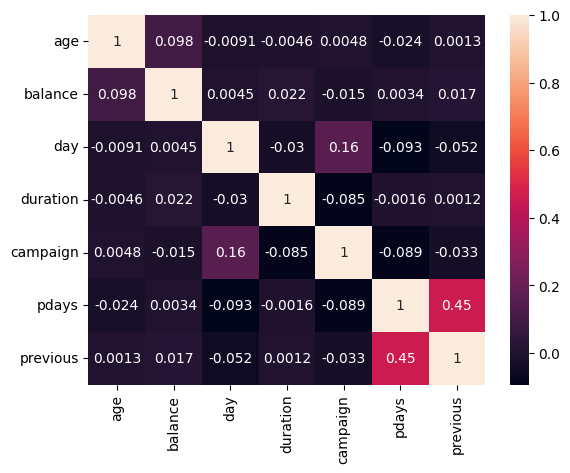

In [163]:
sns.heatmap(df[numerical].corr(), annot=True)

## target encoding

In [164]:
df.y = (df.y == 'yes').astype(int)

## split the data

In [165]:
from sklearn.model_selection import train_test_split
df_full_train, df_test = train_test_split(df, test_size=0.2, random_state=42)
df_train, df_val = train_test_split(df_full_train, test_size=0.25, random_state=42)
len(df_train), len(df_val), len(df_test)

(27126, 9042, 9043)

In [166]:
df_train = df_train.reset_index(drop=True)
df_val = df_val.reset_index(drop=True)
df_test = df_test.reset_index(drop=True)

In [167]:
y_train = df_train.y.values
y_val = df_val.y.values
y_test = df_test.y.values

del df_train['y']
del df_val['y']
del df_test['y']

## Question 3

In [168]:
from sklearn.metrics import mutual_info_score
def mutual_info_churn_score(series):
    return mutual_info_score(series, y_train)

In [169]:
categorical = list(df.dtypes[df.dtypes == 'object'].index)
categorical

['job', 'marital', 'education', 'housing', 'contact', 'month', 'poutcome']

In [170]:

mi = df_train[categorical].apply(mutual_info_churn_score)
mi.sort_values(ascending=False).round(2)

poutcome     0.03
month        0.03
contact      0.01
housing      0.01
job          0.01
education    0.00
marital      0.00
dtype: float64

## Question 4

In [171]:
from sklearn.feature_extraction import DictVectorizer

In [172]:
dv = DictVectorizer(sparse=False)

train_dict = df_train[categorical + numerical].to_dict(orient='records')
X_train = dv.fit_transform(train_dict)

val_dict = df_val[categorical + numerical].to_dict(orient='records')
X_val = dv.transform(val_dict)

In [173]:
from sklearn.linear_model import LogisticRegression

In [174]:
model = LogisticRegression(solver='liblinear', C=1.0, max_iter=1000, random_state=42)
model.fit(X_train, y_train)

LogisticRegression(max_iter=1000, random_state=42, solver='liblinear')

In [175]:
from sklearn.metrics import accuracy_score

y_pred = model.predict(X_val)
accuracy = round(accuracy_score(y_val, y_pred) ,2)
accuracy

0.9

In [176]:
y_pred = model.predict_proba(X_val)[:, 1]
churn_decision = (y_pred >= 0.5)

df_pred = pd.DataFrame()
df_pred['probability'] = y_pred
df_pred['prediction'] = churn_decision.astype(int)
df_pred['actual'] = y_val
df_pred['correct'] = df_pred.prediction == df_pred.actual

df_pred.correct.mean().round(2)

np.float64(0.9)

## Question 5

In [177]:
features = df_train.columns.to_list()
features

['age',
 'job',
 'marital',
 'education',
 'balance',
 'housing',
 'contact',
 'day',
 'month',
 'duration',
 'campaign',
 'pdays',
 'previous',
 'poutcome']

In [185]:
original_score = accuracy
scores = pd.DataFrame(columns=['eliminated_feature', 'accuracy', 'difference'])
for feature in features:
    subset = features.copy()
    subset.remove(feature)
    
    dv = DictVectorizer(sparse=False)
    train_dict = df_train[subset].to_dict(orient='records')
    X_train = dv.fit_transform(train_dict)

    val_dict = df_val[subset].to_dict(orient='records')
    X_val = dv.transform(val_dict)

    model = LogisticRegression(solver='liblinear', max_iter=1000, C=10, random_state=42)
    model.fit(X_train, y_train)
    
    y_pred = model.predict(X_val)
    score = accuracy_score(y_val, y_pred)
    
    scores.loc[len(scores)] = [feature, score, original_score - score]

In [186]:
scores.sort_values(by='difference', ascending=True)

,eliminated_feature,accuracy,difference
12,previous,0.901460,-0.001460
1,job,0.901239,-0.001239
7,day,0.901239,-0.001239
5,housing,0.901239,-0.001239
11,pdays,0.901239,-0.001239
2,marital,0.901017,-0.001017
4,balance,0.900907,-0.000907
0,age,0.900907,-0.000907
3,education,0.900796,-0.000796
6,contact,0.900686,-0.000686


## Question 6

In [188]:
accuracies = pd.DataFrame(columns=['C', 'accuracy'])
for C in [0.01, 0.1, 1, 10, 100]:
    model = LogisticRegression(solver='liblinear', C=C, max_iter=1000, random_state=42)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_val)
    accuracy = accuracy_score(y_val, y_pred)
    accuracies.loc[len(accuracies)] = [C, round(accuracy,3)]

In [189]:
display(accuracies.sort_values(by="accuracy"))


,C,accuracy
0,0.01,0.891
2,1.00,0.893
1,0.10,0.894
3,10.00,0.894
4,100.00,0.894
